# Leadership Style Coach — Exploratory Data Analysis

**Project:** Leadership Style Coach: University Edition
**Author:** Romero Habib
**Supervisor:** Dr. Rachad
**Dataset:** CrossCultural_Leadership_Dataset_5k_2.csv (Global Cultural Leadership Insights, Kaggle)

This notebook performs exploratory data analysis on the leadership dataset prior to model training, in support of Research Hypothesis H1 (classification accuracy) and to inform the design of the scenario-based student assessment.

## 1. Setup and Imports

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.facecolor'] = 'white'
sns.set_style("whitegrid")
sns.set_palette(["#1B6B3A", "#2E8B57", "#5DCAA5", "#A8D8C0", "#D6E4F0"])

pd.set_option('display.max_columns', None)
print("Libraries loaded successfully.")

Libraries loaded successfully.


## 2. Load the Dataset

The dataset is loaded directly from the local `data/` folder. It was sourced from Kaggle's Global Cultural Leadership Insights dataset.

In [19]:
df = pd.read_csv('/content/CrossCultural_Leadership_Dataset_5k 2.csv')
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (6945, 21)


,Respondent_ID,Country,Age,Gender,Education_Level,Work_Experience_Years,Position_Level,Power_Distance,Individualism,Masculinity,Uncertainty_Avoidance,Long_Term_Orientation,Indulgence,Role_Assumption,Production_Emphasis,Initiation_of_Structure,Tolerance_of_Uncertainty,Integration,Consideration,Preferred_Leadership_Behavior,Leadership_Behavior_Encoded
0,1,JPN,48,Male,Bachelor,2,Junior,49.237890,76.184855,79.109461,67.570199,63.725145,81.127194,2,1,2,1,5,4,Supportive,1
1,2,NGA,37,Male,Master,17,Mid,33.799925,55.908143,46.509419,28.581223,9.720500,0.471008,5,4,5,1,5,5,Transformational,3
2,3,IND,50,Female,Bachelor,11,Mid,58.183617,28.382884,43.504239,70.526719,71.401878,68.590050,4,5,1,4,5,2,Transactional,2
3,4,BRA,53,Female,Master,12,Senior,50.932980,50.649410,17.672751,49.884039,57.383845,23.027370,1,2,1,3,1,2,Laissez-Faire,0
4,5,USA,52,Male,Master,3,Junior,34.265389,64.136683,84.120940,46.735180,30.049324,96.774426,4,4,2,5,3,3,Transactional,2


## 3. Dataset Structure

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6945 entries, 0 to 6944
Data columns (total 21 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Respondent_ID                  6945 non-null   int64  
 1   Country                        6945 non-null   object 
 2   Age                            6945 non-null   int64  
 3   Gender                         6945 non-null   object 
 4   Education_Level                6945 non-null   object 
 5   Work_Experience_Years          6945 non-null   int64  
 6   Position_Level                 6945 non-null   object 
 7   Power_Distance                 6945 non-null   float64
 8   Individualism                  6945 non-null   float64
 9   Masculinity                    6945 non-null   float64
 10  Uncertainty_Avoidance          6945 non-null   float64
 11  Long_Term_Orientation          6945 non-null   float64
 12  Indulgence                     6945 non-null   f

In [21]:
df.dtypes

,0
Respondent_ID,int64
Country,object
Age,int64
Gender,object
Education_Level,object
Work_Experience_Years,int64
Position_Level,object
Power_Distance,float64
Individualism,float64
Masculinity,float64


## 4. Missing Value Check

In [22]:
missing = df.isnull().sum()
print(missing)
print("\nTotal missing values in dataset:", missing.sum())

Respondent_ID                    0
Country                          0
Age                              0
Gender                           0
Education_Level                  0
Work_Experience_Years            0
Position_Level                   0
Power_Distance                   0
Individualism                    0
Masculinity                      0
Uncertainty_Avoidance            0
Long_Term_Orientation            0
Indulgence                       0
Role_Assumption                  0
Production_Emphasis              0
Initiation_of_Structure          0
Tolerance_of_Uncertainty         0
Integration                      0
Consideration                    0
Preferred_Leadership_Behavior    0
Leadership_Behavior_Encoded      0
dtype: int64

Total missing values in dataset: 0


**Finding:** The dataset contains zero missing values across all 21 columns and 6,945 rows. No imputation or missing-data handling is required.

## 5. Target Variable: Preferred Leadership Behavior

This is the variable our classification model will predict. Note that the dataset's actual class labels differ from our original proposal's framework (Transformational, Transactional, Servant, Situational). Following discussion with the academic supervisor, the project's hypotheses and framework were updated to match the four classes that genuinely exist in the data: **Supportive, Transactional, Laissez-Faire, and Transformational.**

In [23]:
print(df['Preferred_Leadership_Behavior'].value_counts())
print()
print("Class proportions:")
print(df['Preferred_Leadership_Behavior'].value_counts(normalize=True).round(3))

Preferred_Leadership_Behavior
Supportive          2802
Transactional       1775
Laissez-Faire       1411
Transformational     957
Name: count, dtype: int64

Class proportions:
Preferred_Leadership_Behavior
Supportive          0.403
Transactional       0.256
Laissez-Faire       0.203
Transformational    0.138
Name: proportion, dtype: float64


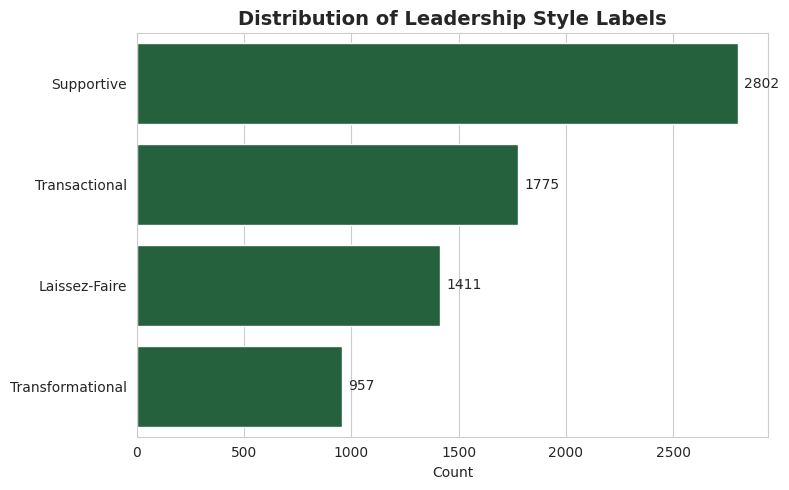

In [24]:
fig, ax = plt.subplots(figsize=(8,5))
order = df['Preferred_Leadership_Behavior'].value_counts().index
sns.countplot(data=df, y='Preferred_Leadership_Behavior', order=order, ax=ax, color="#1B6B3A")
ax.set_title("Distribution of Leadership Style Labels", fontsize=14, fontweight='bold')
ax.set_xlabel("Count")
ax.set_ylabel("")
for i, v in enumerate(df['Preferred_Leadership_Behavior'].value_counts()[order]):
    ax.text(v + 30, i, str(v), va='center', fontsize=10)
plt.tight_layout()
plt.savefig('/content/eda_outputs/01_class_distribution.png', dpi=150)
plt.show()

**Finding:** The dataset is imbalanced. Supportive is the majority class at 40.4% (2,802 instances), while Transformational is the minority class at 13.8% (957 instances). This has two implications for the project:

1. The majority-class baseline (always predicting "Supportive") will achieve approximately 40% accuracy. This sets a higher bar than the originally proposed random baseline (25%), consistent with Dr. Rachad's feedback to use stronger baselines.
2. Model evaluation must rely on macro-averaged precision, recall, and F1 score, not raw accuracy alone, to ensure the minority class (Transformational) is fairly assessed.

## 6. Demographic Feature Overview

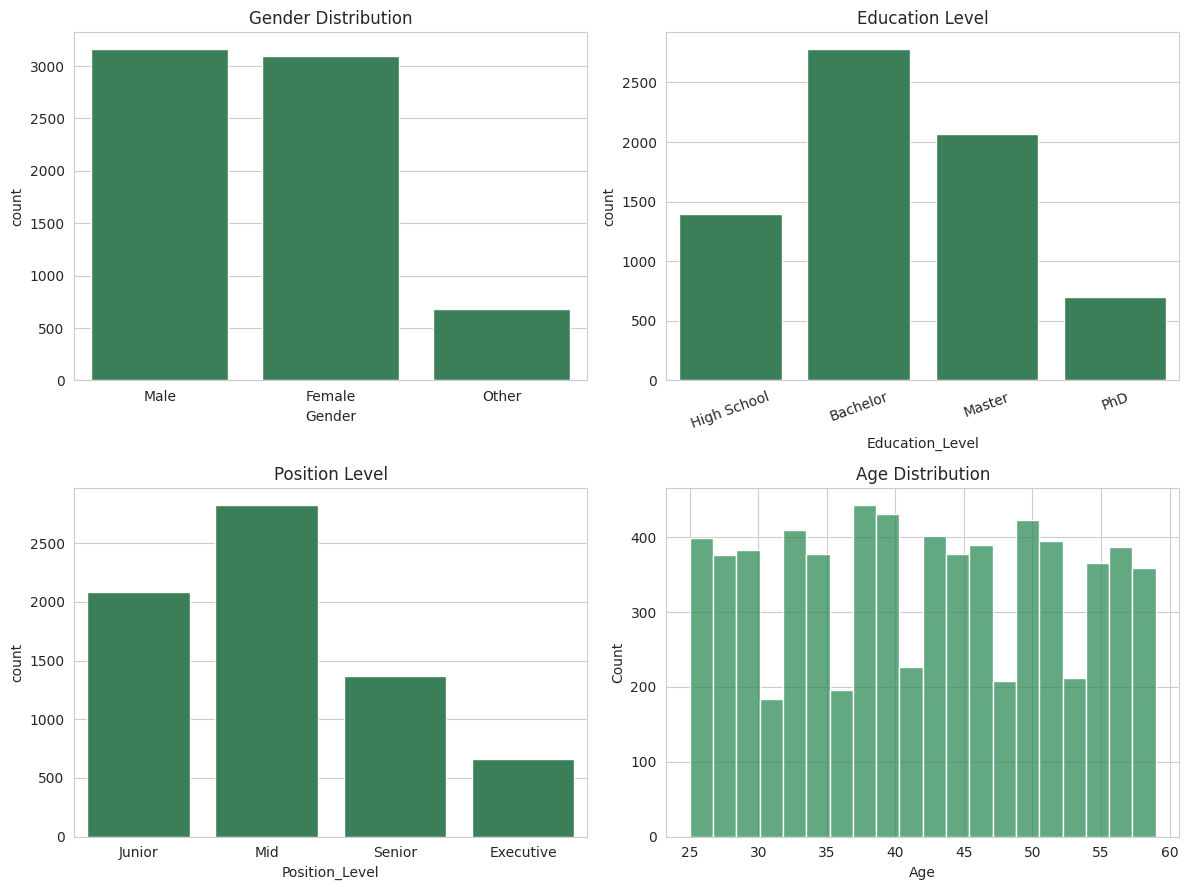

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(12,9))
sns.countplot(data=df, x='Gender', ax=axes[0,0], color="#2E8B57")
axes[0,0].set_title("Gender Distribution")
sns.countplot(data=df, x='Education_Level', ax=axes[0,1], order=['High School','Bachelor','Master','PhD'], color="#2E8B57")
axes[0,1].set_title("Education Level")
axes[0,1].tick_params(axis='x', rotation=20)
sns.countplot(data=df, x='Position_Level', ax=axes[1,0], order=['Junior','Mid','Senior','Executive'], color="#2E8B57")
axes[1,0].set_title("Position Level")
sns.histplot(data=df, x='Age', bins=20, ax=axes[1,1], color="#2E8B57")
axes[1,1].set_title("Age Distribution")
plt.tight_layout()
plt.savefig('/content/eda_outputs/02_demographics.png', dpi=150)
plt.show()

**Finding:** Respondents are well distributed across gender, education level, position level, and age, with no single category dominating. This makes the dataset representative across a range of demographic profiles.

## 7. Hofstede Cultural Dimension Distributions

The dataset includes six Hofstede cultural dimensions (Power Distance, Individualism, Masculinity, Uncertainty Avoidance, Long-Term Orientation, Indulgence), each scored on a continuous 0-100 scale.

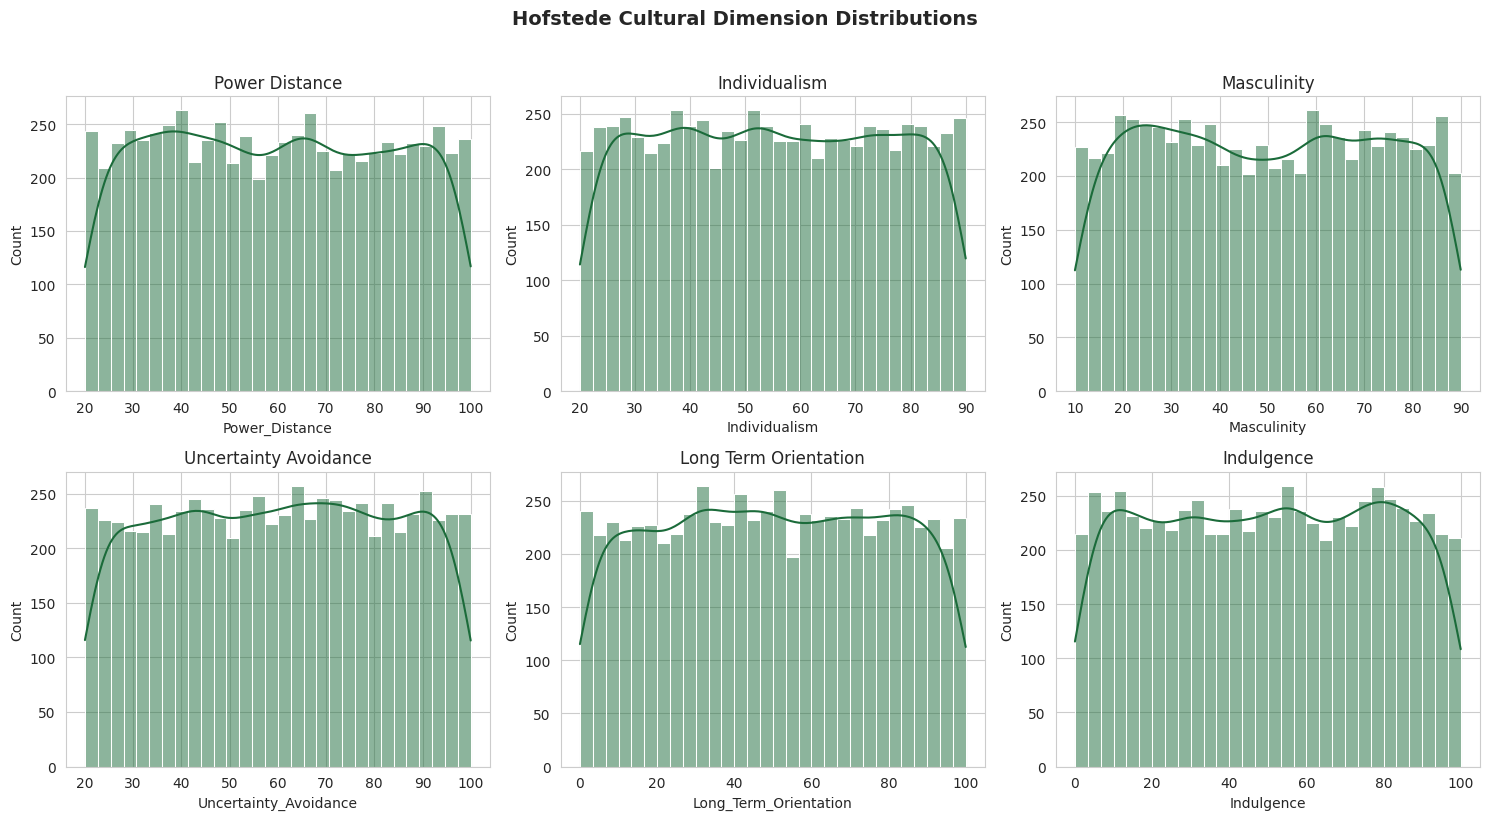

In [26]:
cult_cols = ['Power_Distance','Individualism','Masculinity','Uncertainty_Avoidance','Long_Term_Orientation','Indulgence']
fig, axes = plt.subplots(2, 3, figsize=(15,8))
for ax, col in zip(axes.flat, cult_cols):
    sns.histplot(df[col], bins=30, ax=ax, color="#1B6B3A", kde=True)
    ax.set_title(col.replace('_',' '))
plt.suptitle("Hofstede Cultural Dimension Distributions", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/content/eda_outputs/03_cultural_dimensions.png', dpi=150)
plt.show()

**Finding:** All six cultural dimensions are roughly uniformly distributed between 0 and 100, consistent with synthetically generated cultural scores spanning the full Hofstede range.

## 8. Behavioral Score Distributions

The dataset includes six behavioral scores, each on a 1-5 Likert scale: Role Assumption, Production Emphasis, Initiation of Structure, Tolerance of Uncertainty, Integration, and Consideration. These are the core behavioral indicators that will inform the design of the student scenario-based assessment.

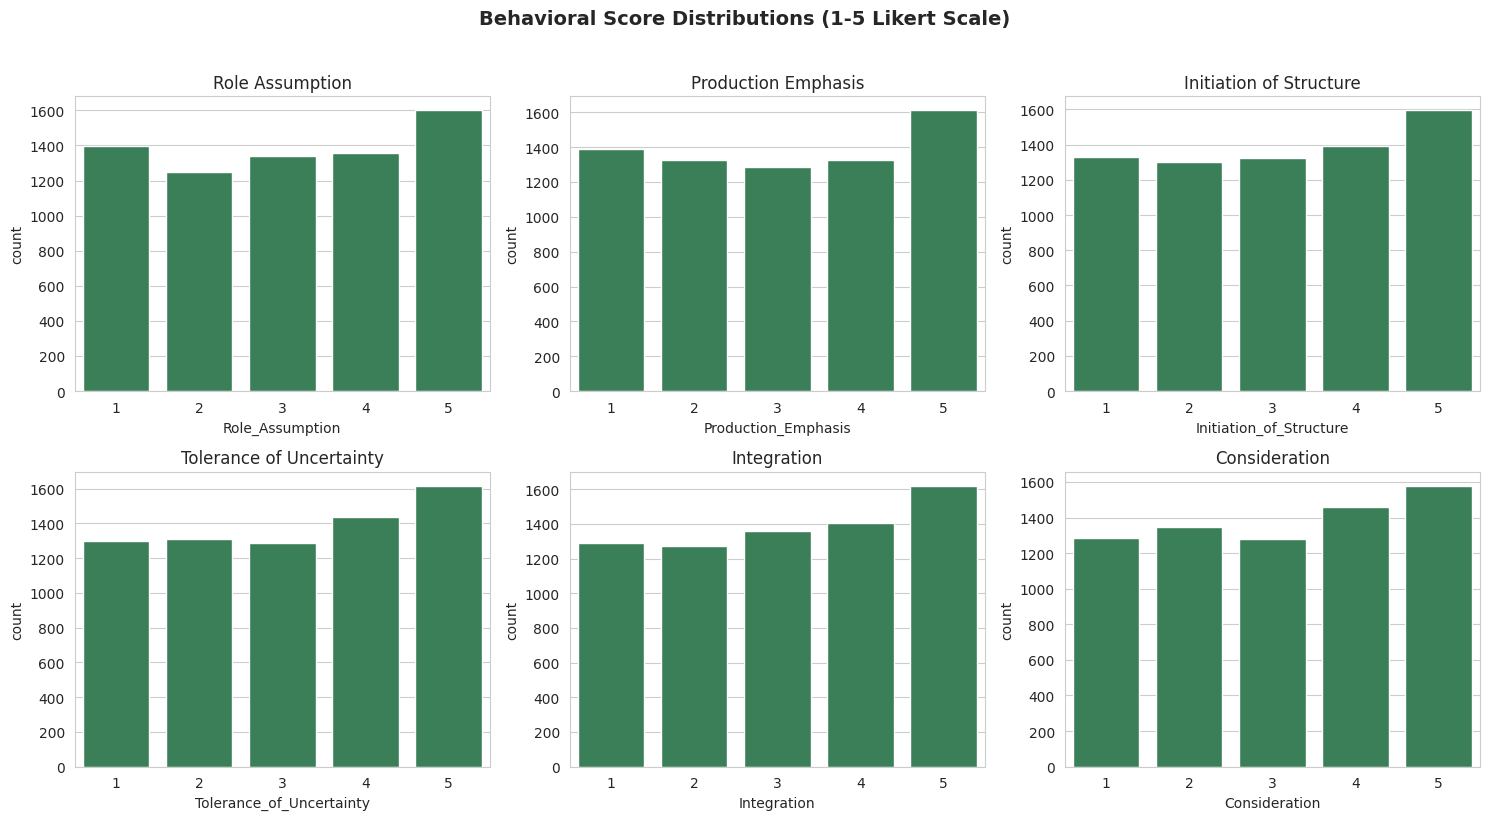

In [27]:
beh_cols = ['Role_Assumption','Production_Emphasis','Initiation_of_Structure','Tolerance_of_Uncertainty','Integration','Consideration']
fig, axes = plt.subplots(2, 3, figsize=(15,8))
for ax, col in zip(axes.flat, beh_cols):
    sns.countplot(x=df[col], ax=ax, color="#2E8B57")
    ax.set_title(col.replace('_',' '))
plt.suptitle("Behavioral Score Distributions (1-5 Likert Scale)", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/content/eda_outputs/04_behavioral_scores.png', dpi=150)
plt.show()

## 9. Correlation Analysis

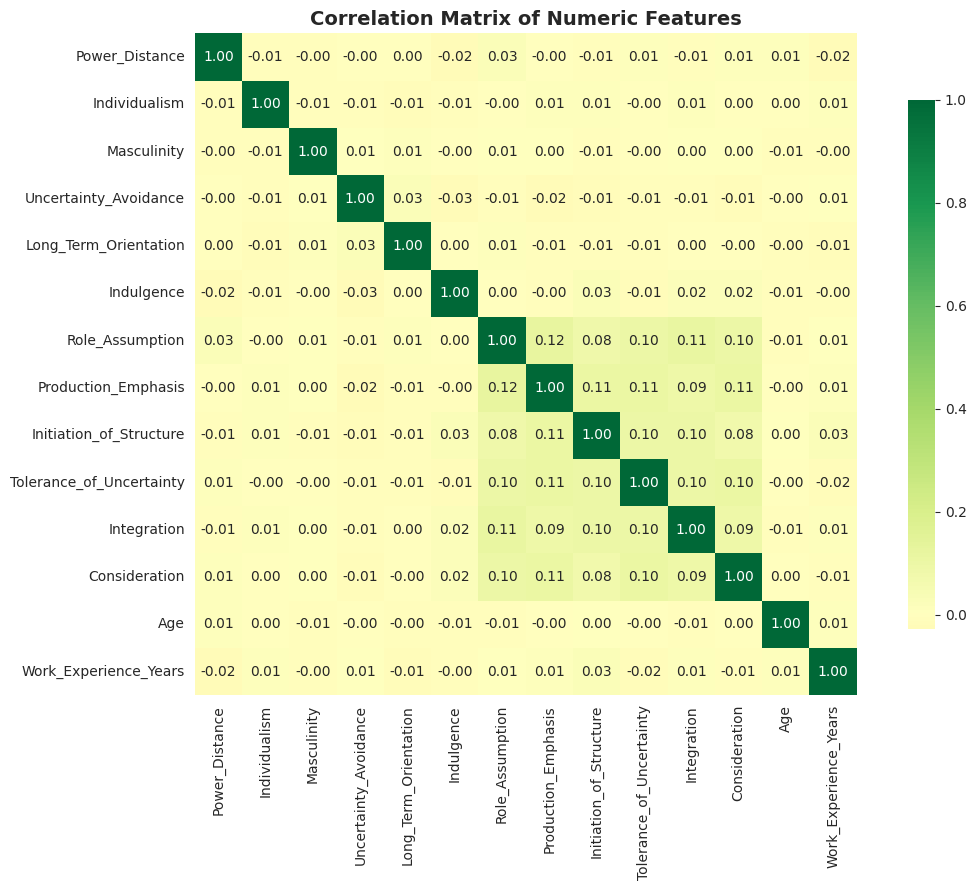

In [28]:
numeric_cols = cult_cols + beh_cols + ['Age','Work_Experience_Years']
corr = df[numeric_cols].corr()
fig, ax = plt.subplots(figsize=(12,9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn", center=0, ax=ax, square=True, cbar_kws={"shrink": .8})
ax.set_title("Correlation Matrix of Numeric Features", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/eda_outputs/05_correlation_heatmap.png', dpi=150)
plt.show()

**Finding:** The six behavioral scores show mild positive correlation with each other (0.08-0.12), consistent with them all relating to leadership behavior. Cultural dimensions show negligible correlation with each other and with behavioral scores. No problematic multicollinearity is present, which supports the use of tree-based models and reliable SHAP interpretation later in the project.

## 10. Behavioral Scores by Leadership Style (Key Finding)

This is the most important analysis in this notebook. It examines whether the six behavioral scores differ meaningfully across the four leadership style classes.

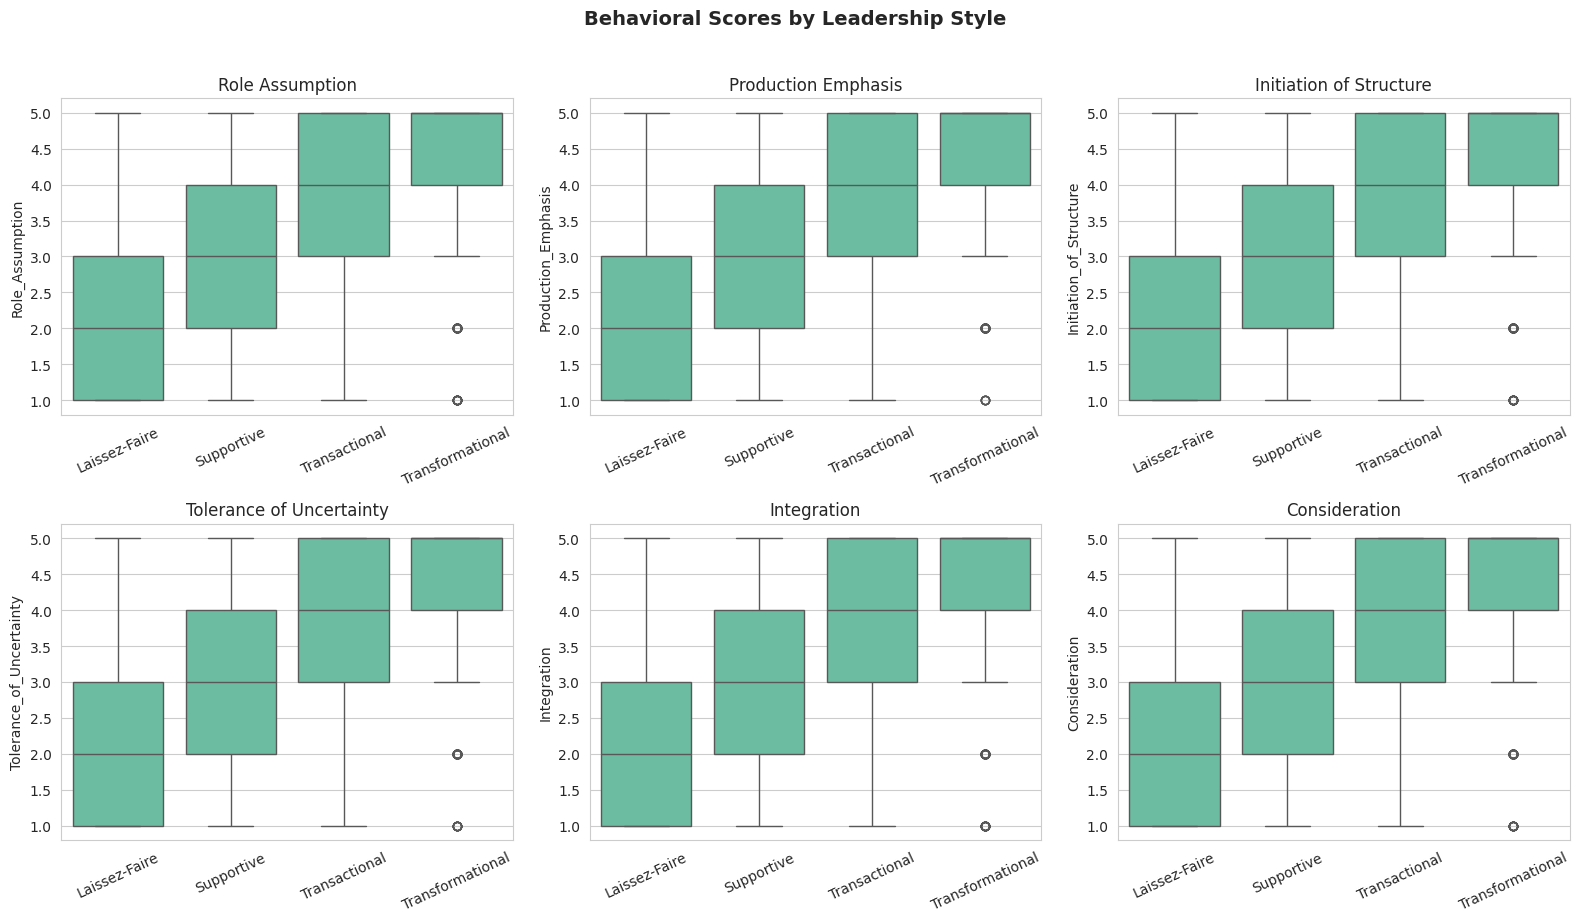

In [29]:
fig, axes = plt.subplots(2, 3, figsize=(16,9))
for ax, col in zip(axes.flat, beh_cols):
    sns.boxplot(data=df, x='Preferred_Leadership_Behavior', y=col, ax=ax,
                order=['Laissez-Faire','Supportive','Transactional','Transformational'],
                color="#5DCAA5")
    ax.set_title(col.replace('_',' '))
    ax.tick_params(axis='x', rotation=25)
    ax.set_xlabel("")
plt.suptitle("Behavioral Scores by Leadership Style", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/content/eda_outputs/06_behavioral_by_class.png', dpi=150)
plt.show()

**Finding:** A clear and consistent pattern emerges across all six behavioral scores. Laissez-Faire respondents score lowest, Supportive respondents score moderately, and Transactional and Transformational respondents score highest, with substantial overlap between the latter two. This indicates that the six behavioral scores carry strong predictive signal for distinguishing leadership styles, and that Transactional and Transformational may be the hardest pair for the model to separate.

## 11. Hofstede Cultural Dimensions by Leadership Style

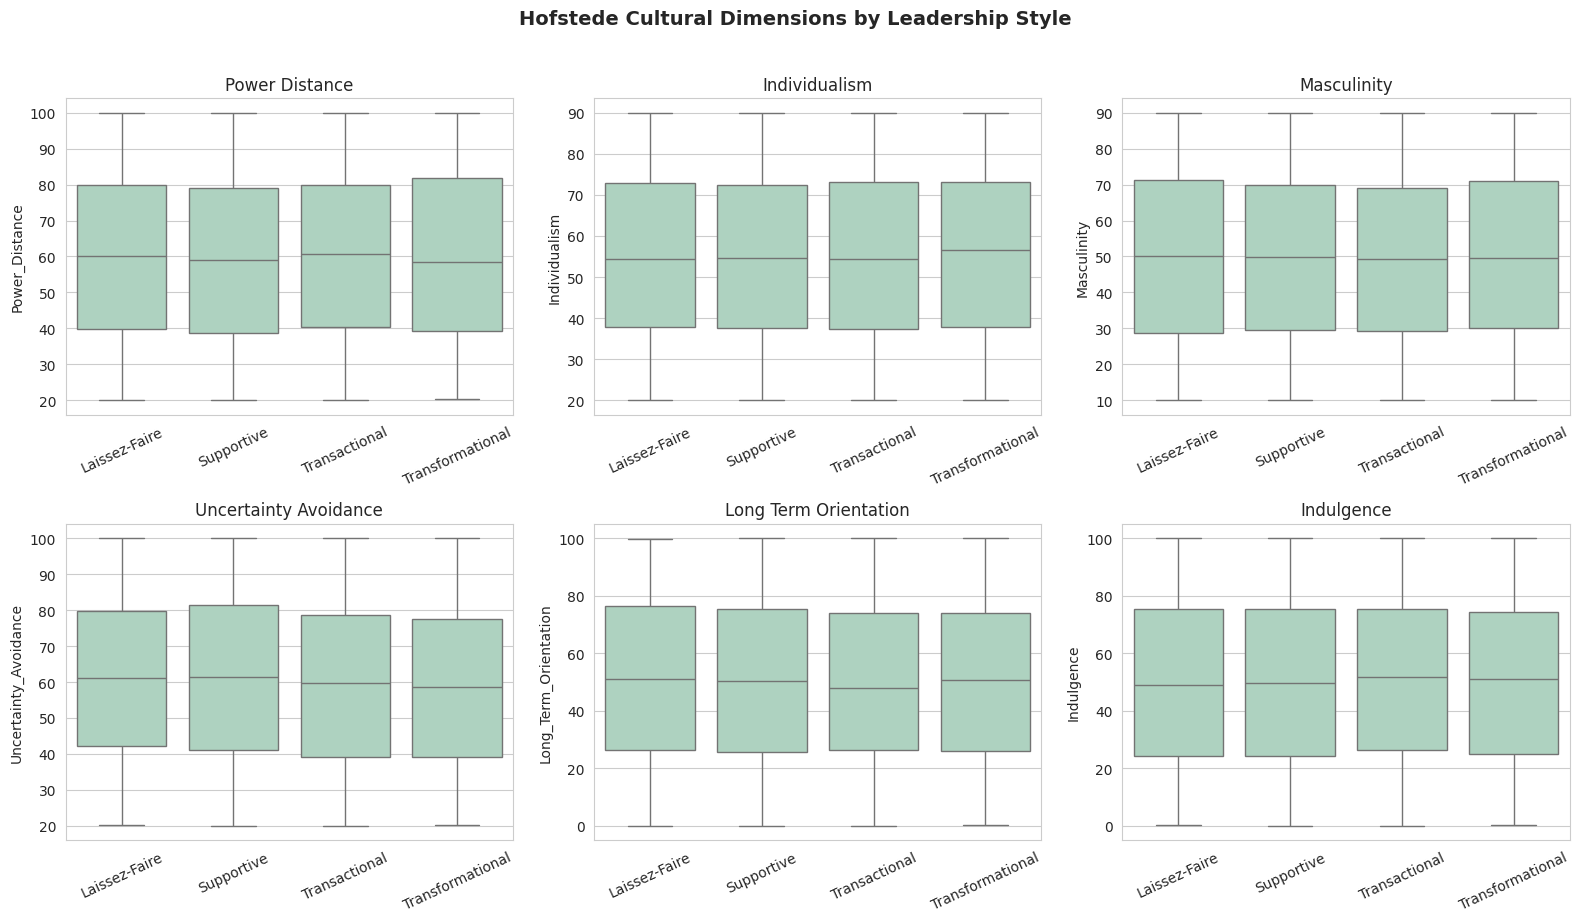

In [30]:
fig, axes = plt.subplots(2, 3, figsize=(16,9))
for ax, col in zip(axes.flat, cult_cols):
    sns.boxplot(data=df, x='Preferred_Leadership_Behavior', y=col, ax=ax,
                order=['Laissez-Faire','Supportive','Transactional','Transformational'],
                color="#A8D8C0")
    ax.set_title(col.replace('_',' '))
    ax.tick_params(axis='x', rotation=25)
    ax.set_xlabel("")
plt.suptitle("Hofstede Cultural Dimensions by Leadership Style", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/content/eda_outputs/08_cultural_by_class.png', dpi=150)
plt.show()

In [31]:
means = df.groupby('Preferred_Leadership_Behavior')[cult_cols].mean().round(1)
means

,Power_Distance,Individualism,Masculinity,Uncertainty_Avoidance,Long_Term_Orientation,Indulgence
Preferred_Leadership_Behavior,,,,,,
Laissez-Faire,60.0,55.0,50.1,60.8,50.6,49.7
Supportive,59.1,54.8,49.8,60.9,50.3,49.5
Transactional,60.3,55.0,49.4,59.6,49.7,50.7
Transformational,60.4,55.7,50.4,58.8,50.0,49.9


**Finding:** Unlike the behavioral scores, the cultural dimensions show almost no separation across leadership style classes. The distributions are nearly identical regardless of class, suggesting that cultural dimensions alone carry little predictive signal for this target variable in this dataset.

## 12. Demographics by Leadership Style

FileNotFoundError: [Errno 2] No such file or directory: '../eda_outputs/09_demographics_vs_target.png'

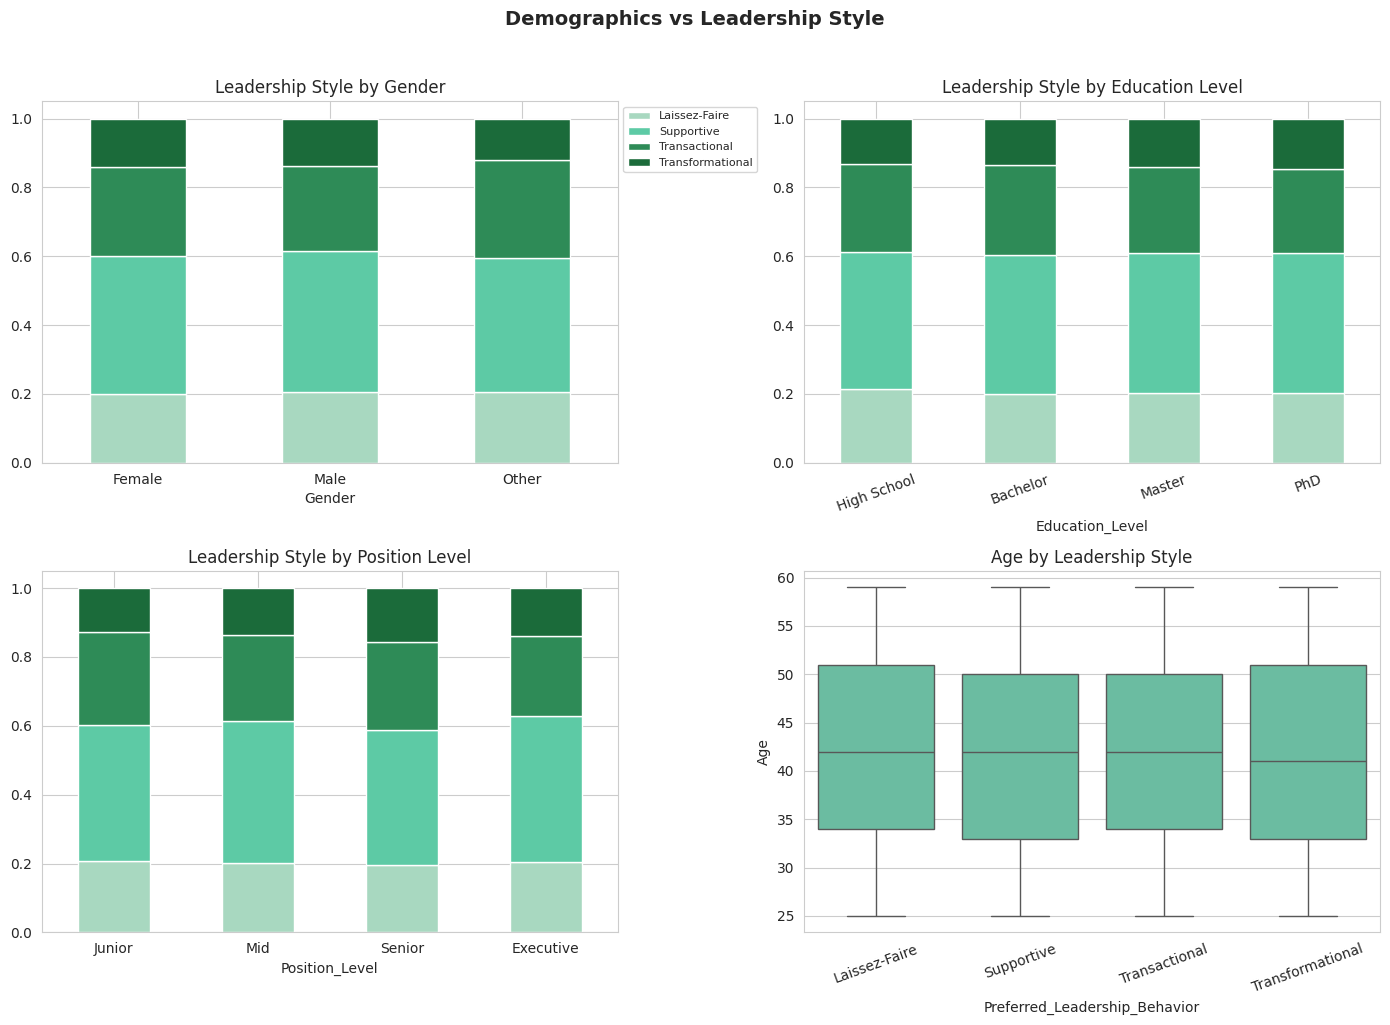

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(14,10))

ct1 = pd.crosstab(df['Gender'], df['Preferred_Leadership_Behavior'], normalize='index')
ct1 = ct1[['Laissez-Faire','Supportive','Transactional','Transformational']]
ct1.plot(kind='bar', stacked=True, ax=axes[0,0], color=["#A8D8C0","#5DCAA5","#2E8B57","#1B6B3A"])
axes[0,0].set_title("Leadership Style by Gender")
axes[0,0].legend(loc='upper left', bbox_to_anchor=(1,1), fontsize=8)
axes[0,0].tick_params(axis='x', rotation=0)

ct2 = pd.crosstab(df['Education_Level'], df['Preferred_Leadership_Behavior'], normalize='index')
ct2 = ct2.reindex(['High School','Bachelor','Master','PhD'])
ct2 = ct2[['Laissez-Faire','Supportive','Transactional','Transformational']]
ct2.plot(kind='bar', stacked=True, ax=axes[0,1], color=["#A8D8C0","#5DCAA5","#2E8B57","#1B6B3A"])
axes[0,1].set_title("Leadership Style by Education Level")
axes[0,1].legend().remove()
axes[0,1].tick_params(axis='x', rotation=20)

ct3 = pd.crosstab(df['Position_Level'], df['Preferred_Leadership_Behavior'], normalize='index')
ct3 = ct3.reindex(['Junior','Mid','Senior','Executive'])
ct3 = ct3[['Laissez-Faire','Supportive','Transactional','Transformational']]
ct3.plot(kind='bar', stacked=True, ax=axes[1,0], color=["#A8D8C0","#5DCAA5","#2E8B57","#1B6B3A"])
axes[1,0].set_title("Leadership Style by Position Level")
axes[1,0].legend().remove()
axes[1,0].tick_params(axis='x', rotation=0)

sns.boxplot(data=df, x='Preferred_Leadership_Behavior', y='Age', ax=axes[1,1],
            order=['Laissez-Faire','Supportive','Transactional','Transformational'], color="#5DCAA5")
axes[1,1].set_title("Age by Leadership Style")
axes[1,1].tick_params(axis='x', rotation=20)

plt.suptitle("Demographics vs Leadership Style", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../eda_outputs/09_demographics_vs_target.png', dpi=150)
plt.show()

**Finding:** Gender, education level, position level, and age show no meaningful relationship with leadership style. Class proportions remain nearly identical across all demographic subgroups.

In [ ]:
ct = pd.crosstab(df['Country'], df['Preferred_Leadership_Behavior'], normalize='index').round(2)
ct = ct[['Laissez-Faire','Supportive','Transactional','Transformational']]
ct

**Finding:** Country also shows no meaningful variation in class proportions, confirming that geographic and cultural background does not meaningfully predict leadership style in this dataset.

## 13. EDA Summary and Implications for Modeling

| Feature Group | Predictive Signal | Decision |
|---|---|---|
| Behavioral scores (6 features) | Strong, consistent separation across classes | Core input features for the model and the basis for the student assessment questions |
| Hofstede cultural dimensions (6 features) | Negligible separation | Retained as features for completeness, but expected to receive low SHAP importance |
| Demographics (gender, education, position, age) | Negligible separation | Retained as features for completeness, but expected to receive low SHAP importance |
| Country | Negligible separation | Retained as a categorical feature, expected to receive low SHAP importance |

**Conclusion:** This EDA confirms that the dataset's predictive signal for leadership style is concentrated almost entirely in the six behavioral score features. This directly informs two downstream decisions: the scenario-based student assessment will be designed primarily to capture these six behavioral dimensions, and the SHAP explainability analysis (H2) is expected to rank these six features substantially higher in importance than the cultural and demographic features.

The next notebook in this project will cover feature engineering, baseline model training (majority-class, logistic regression, decision tree), and the proposed classifier (Random Forest / XGBoost), in support of Research Hypothesis H1.